<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/gold_TIPSrealyields_correlations_maxDD_Sharpe_strategybacktests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


Datos: 2018-01-03 → 2026-06-22  (2112 obs)
         Gold_ret  Yield_diff
count  2112.00000  2112.00000
mean      0.00055     0.00086
std       0.01098     0.05107
min      -0.12066    -0.45000
25%      -0.00435    -0.03000
50%       0.00072     0.00000
75%       0.00611     0.03000
max       0.05905     0.39000

Pearson  Gold_ret ~ Yield_diff : -0.2939
Spearman Gold_ret ~ Yield_diff : -0.3200


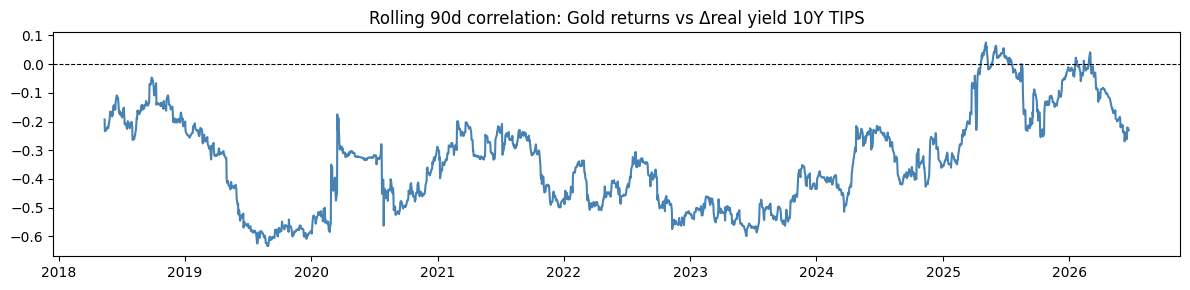

ADF Gold_ret: stat=-12.485  p=0.0000  ✓ estacionaria
ADF Yield_diff: stat=-34.850  p=0.0000  ✓ estacionaria

── ARIMA ──────────────────────────────────────────────
                               SARIMAX Results                                
Dep. Variable:               Gold_ret   No. Observations:                 2112
Model:                 ARIMA(1, 0, 1)   Log Likelihood                6533.007
Date:                Wed, 24 Jun 2026   AIC                         -13058.014
Time:                        12:51:40   BIC                         -13035.393
Sample:                             0   HQIC                        -13049.731
                               - 2112                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.313  

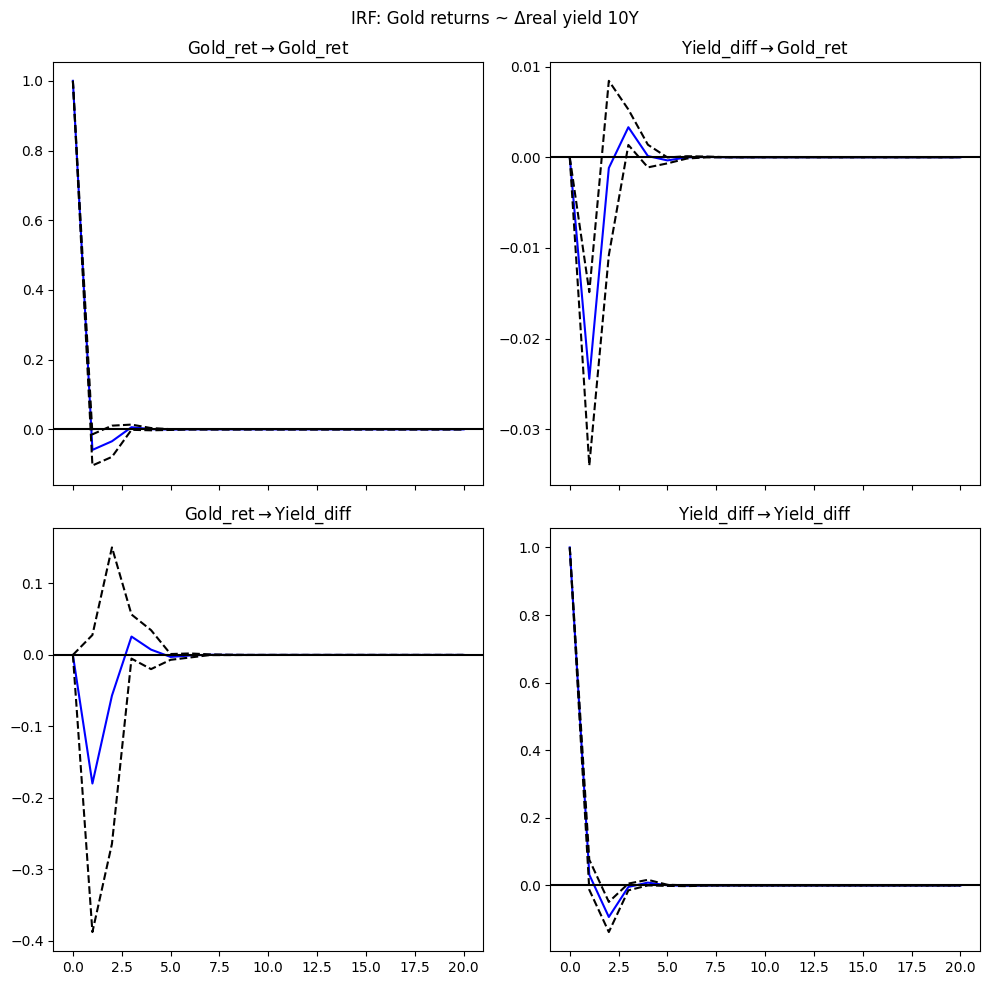


  SEÑAL HOY        : FLAT
  ARIMA forecast   : +0.00111
  VAR   forecast   : +0.00086
  GARCH vol diaria : 0.0174  (umbral 0.015)

── Backtesting: Oro ~ yields reales TIPS ──────────────
Sharpe anualizado     : -1.723
Max Drawdown          : -107.11%
Hit rate              : 45.0%
Días en mercado       : 562 / 1860
Coste total acumulado : 112.00%


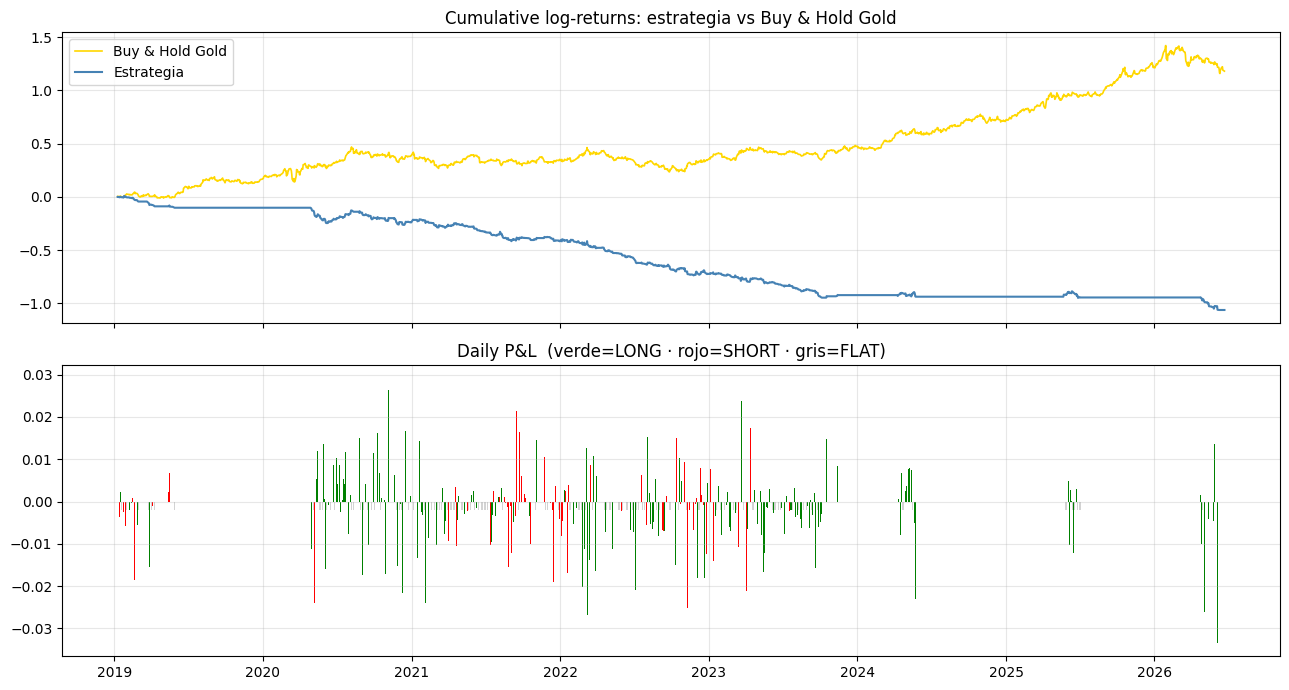

In [4]:
!pip install yfinance
!pip install pandas-datareader
!pip install arch

# ═══════════════════════════════════════════════════════════════
# 1. LIBRERÍAS
# ═══════════════════════════════════════════════════════════════
import yfinance as yf
import pandas_datareader as pdr          # pip install pandas-datareader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

START = '2018-01-01'


# ═══════════════════════════════════════════════════════════════
# 2. DATOS
# ═══════════════════════════════════════════════════════════════


# Oro
gold_raw = yf.download('GC=F', start=START, auto_adjust=True)['Close']
gold = gold_raw.squeeze()                        # asegura que es Series, no DataFrame
gold.index = pd.to_datetime(gold.index).tz_localize(None)   # elimina timezone si existe
gold.name = 'Gold'

# Yield real 10Y TIPS desde FRED
tips_raw = pdr.get_data_fred('DFII10', start=START)
tips = tips_raw['DFII10'].squeeze()
tips.index = pd.to_datetime(tips.index).tz_localize(None)
tips.name = 'RealYield'

# Unir explícitamente como Series antes de construir el DataFrame
df = pd.concat([gold, tips], axis=1).dropna()
df.columns = ['Gold', 'RealYield']

# Returns
df['Gold_ret']   = np.log(df['Gold'] / df['Gold'].shift(1))
df['Yield_diff'] = df['RealYield'].diff()
df.dropna(inplace=True)

print(f"Datos: {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} obs)")
print(df[['Gold_ret', 'Yield_diff']].describe().round(5))


# ═══════════════════════════════════════════════════════════════
# 3. ANÁLISIS EXPLORATORIO
# ═══════════════════════════════════════════════════════════════

# Correlación — esperamos signo negativo (yield sube → oro baja)
print(f"\nPearson  Gold_ret ~ Yield_diff : {df['Gold_ret'].corr(df['Yield_diff']):.4f}")
print(f"Spearman Gold_ret ~ Yield_diff : {df['Gold_ret'].corr(df['Yield_diff'], method='spearman'):.4f}")

# Correlación rolling 90 días
rolling_corr = df['Gold_ret'].rolling(90).corr(df['Yield_diff'])
plt.figure(figsize=(12, 3))
plt.plot(rolling_corr, color='steelblue')
plt.axhline(0, color='black', lw=0.8, ls='--')
plt.title('Rolling 90d correlation: Gold returns vs Δreal yield 10Y TIPS')
plt.tight_layout(); plt.show()

# Test ADF
for col in ['Gold_ret', 'Yield_diff']:
    stat, p, *_ = adfuller(df[col].dropna())
    print(f"ADF {col}: stat={stat:.3f}  p={p:.4f}  {'✓ estacionaria' if p < 0.05 else '✗ no estacionaria'}")


# ═══════════════════════════════════════════════════════════════
# 4. MODELO 1 — ARIMA
# ═══════════════════════════════════════════════════════════════
print("\n── ARIMA ──────────────────────────────────────────────")

model_arima = ARIMA(df['Gold_ret'], order=(1, 0, 1)).fit()
fc_arima    = model_arima.get_forecast(steps=1)
mu_arima    = fc_arima.predicted_mean.iloc[0]
ci_arima    = fc_arima.conf_int(alpha=0.05)

print(model_arima.summary())
print(f"\nForecast return h=1 : {mu_arima:+.5f}")
print(f"IC 95%              : [{ci_arima.iloc[0,0]:+.5f}, {ci_arima.iloc[0,1]:+.5f}]")


# ═══════════════════════════════════════════════════════════════
# 5. MODELO 2 — GARCH
# ═══════════════════════════════════════════════════════════════
print("\n── GARCH ──────────────────────────────────────────────")

gold_scaled = df['Gold_ret'] * 100

model_garch  = arch_model(gold_scaled.dropna(), vol='Garch', p=1, q=1).fit(disp='off')
fc_garch     = model_garch.forecast(horizon=1, reindex=False)
var_h1       = fc_garch.variance.iloc[-1, 0]
sigma_daily  = np.sqrt(var_h1) / 100
sigma_annual = sigma_daily * np.sqrt(252)

print(model_garch.summary())
print(f"\nVol diaria     : {sigma_daily:.4f}  ({sigma_daily*100:.2f}%)")
print(f"Vol anualizada : {sigma_annual:.4f}  ({sigma_annual*100:.2f}%)")


# ═══════════════════════════════════════════════════════════════
# 6. MODELO 3 — ARX
# ═══════════════════════════════════════════════════════════════
print("\n── ARX ────────────────────────────────────────────────")

# X = Yield_diff; supuesto random walk → último Δyield conocido
model_arx = ARIMA(df['Gold_ret'], exog=df['Yield_diff'], order=(1, 0, 0)).fit()
last_yield_diff = np.array([[df['Yield_diff'].iloc[-1]]])
fc_arx    = model_arx.get_forecast(steps=1, exog=last_yield_diff)
mu_arx    = fc_arx.predicted_mean.iloc[0]

print(model_arx.summary())
print(f"\nForecast return h=1 (Δyield=rw): {mu_arx:+.5f}")


# ═══════════════════════════════════════════════════════════════
# 7. MODELO 4 — VAR
# ═══════════════════════════════════════════════════════════════
print("\n── VAR ────────────────────────────────────────────────")

data_var    = df[['Gold_ret', 'Yield_diff']]
lag_sel     = VAR(data_var).select_order(maxlags=10)
print(lag_sel.summary())
p_opt       = lag_sel.aic

results_var = VAR(data_var).fit(p_opt)
print(results_var.summary())

fc_var       = results_var.forecast(data_var.values[-p_opt:], steps=1)
mu_var_gold  = fc_var[0][0]
mu_var_yield = fc_var[0][1]
print(f"\nVAR forecast Gold  h=1 : {mu_var_gold:+.5f}")
print(f"VAR forecast Δyield h=1: {mu_var_yield:+.5f}")

print("\n-- Granger: ¿Δyield → Gold? --")
print(results_var.test_causality('Gold_ret', 'Yield_diff', kind='f').summary())

irf = results_var.irf(periods=20)
irf.plot(orth=False)
plt.suptitle('IRF: Gold returns ~ Δreal yield 10Y')
plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════
# 8. SEÑAL DE TRADING (t = hoy)
# ═══════════════════════════════════════════════════════════════
VOL_THRESHOLD = 0.015   # oro: vol diaria típica 0.7-1.2%, umbral 1.5%

if sigma_daily > VOL_THRESHOLD:
    signal = 'FLAT'
elif np.sign(mu_arima) == np.sign(mu_var_gold) == 1:
    signal = 'LONG'
elif np.sign(mu_arima) == np.sign(mu_var_gold) == -1:
    signal = 'SHORT'
else:
    signal = 'FLAT'

print(f"\n{'='*45}")
print(f"  SEÑAL HOY        : {signal}")
print(f"  ARIMA forecast   : {mu_arima:+.5f}")
print(f"  VAR   forecast   : {mu_var_gold:+.5f}")
print(f"  GARCH vol diaria : {sigma_daily:.4f}  (umbral {VOL_THRESHOLD})")
print(f"{'='*45}")


# ═══════════════════════════════════════════════════════════════
# 9. BACKTESTING — walk-forward out-of-sample
# ═══════════════════════════════════════════════════════════════
TRAIN_WINDOW   = 252
VOL_THRESHOLD  = 0.015
COST_PER_TRADE = 0.002   # 0.2% comisiones + slippage por operación

results_bt = []

for i in range(TRAIN_WINDOW, len(df)):
    window = df.iloc[i - TRAIN_WINDOW : i]
    today  = df.iloc[i]

    # ARIMA
    try:
        ar    = ARIMA(window['Gold_ret'], order=(1, 0, 1)).fit()
        mu_ar = ar.forecast(steps=1).iloc[0]
    except:
        mu_ar = 0

    # GARCH
    try:
        ga  = arch_model(window['Gold_ret'] * 100, vol='Garch', p=1, q=1).fit(disp='off')
        v   = ga.forecast(horizon=1, reindex=False).variance.iloc[-1, 0]
        sig = np.sqrt(v) / 100
    except:
        sig = VOL_THRESHOLD + 1

    # VAR
    try:
        va     = VAR(window[['Gold_ret', 'Yield_diff']]).fit(maxlags=5, ic='aic')
        fc_v   = va.forecast(window[['Gold_ret', 'Yield_diff']].values[-va.k_ar:], steps=1)
        mu_var = fc_v[0][0]
    except:
        mu_var = 0

    # Señal
    if sig > VOL_THRESHOLD:
        sig_label = 'FLAT'
    elif np.sign(mu_ar) == np.sign(mu_var) == 1:
        sig_label = 'LONG'
    elif np.sign(mu_ar) == np.sign(mu_var) == -1:
        sig_label = 'SHORT'
    else:
        sig_label = 'FLAT'

    pos      = {'LONG': 1, 'SHORT': -1, 'FLAT': 0}[sig_label]
    prev_pos = results_bt[-1]['position'] if results_bt else 0
    cost     = COST_PER_TRADE if pos != prev_pos else 0
    ret_strat = pos * today['Gold_ret'] - cost

    results_bt.append({
        'date':         today.name,
        'signal':       sig_label,
        'position':     pos,
        'Gold_ret':     today['Gold_ret'],
        'strategy_ret': ret_strat,
        'cost':         cost,
    })

bt = pd.DataFrame(results_bt).set_index('date')

# Métricas
bt['cum_strategy'] = bt['strategy_ret'].cumsum()
bt['cum_bh']       = bt['Gold_ret'].cumsum()

sharpe   = bt['strategy_ret'].mean() / bt['strategy_ret'].std() * np.sqrt(252)
max_dd   = (bt['cum_strategy'] - bt['cum_strategy'].cummax()).min()
hit_rate = (bt.loc[bt['position'] != 0, 'strategy_ret'] > 0).mean()
n_trades = (bt['position'] != 0).sum()
total_costs = bt['cost'].sum()

print(f"\n── Backtesting: Oro ~ yields reales TIPS ──────────────")
print(f"Sharpe anualizado     : {sharpe:.3f}")
print(f"Max Drawdown          : {max_dd*100:.2f}%")
print(f"Hit rate              : {hit_rate*100:.1f}%")
print(f"Días en mercado       : {n_trades} / {len(bt)}")
print(f"Coste total acumulado : {total_costs*100:.2f}%")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(bt['cum_bh'],       label='Buy & Hold Gold', color='gold',      lw=1.2)
axes[0].plot(bt['cum_strategy'], label='Estrategia',      color='steelblue', lw=1.5)
axes[0].set_title('Cumulative log-returns: estrategia vs Buy & Hold Gold')
axes[0].legend(); axes[0].grid(alpha=0.3)

colors = bt['signal'].map({'LONG': 'green', 'SHORT': 'red', 'FLAT': 'lightgray'})
axes[1].bar(bt.index, bt['strategy_ret'], color=colors, width=1)
axes[1].set_title('Daily P&L  (verde=LONG · rojo=SHORT · gris=FLAT)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()